In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [ ]:
ticker = 'AMZN'
df = yf.download(ticker, '2020-01-01')

/tmp/ipykernel_1035/3443383388.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, '2020-01-01')
[*********************100%***********************]  1 of 1 completed


In [ ]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,
2020-01-02,94.900497,94.900497,93.207497,93.750000,80580000
2020-01-03,93.748497,94.309998,93.224998,93.224998,75288000
2020-01-06,95.143997,95.184502,93.000000,93.000000,81236000
2020-01-07,95.343002,95.694504,94.601997,95.224998,80898000
2020-01-08,94.598503,95.550003,94.321999,94.902000,70160000


<Axes: xlabel='Date'>

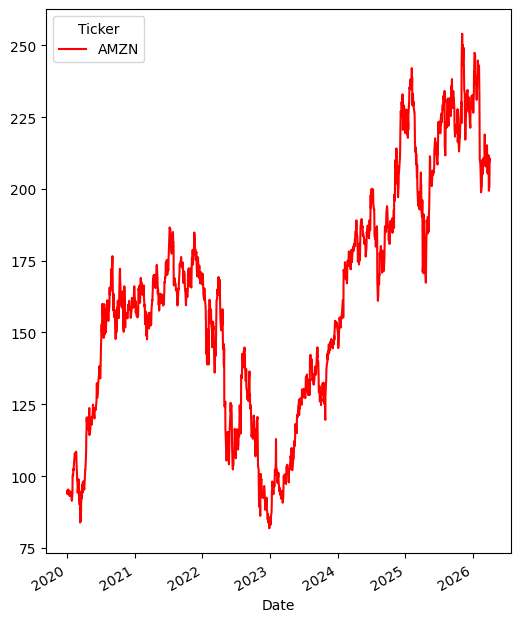

In [ ]:
df.Close.plot(figsize=(6,8), color = 'red')

In [ ]:
scaler = StandardScaler()

In [ ]:
df["Close"] = scaler.fit_transform(df[["Close"]])

In [ ]:
df.Close

Ticker,AMZN
Date,
2020-01-02,-1.606958
2020-01-03,-1.634991
2020-01-06,-1.601033
2020-01-07,-1.596190
2020-01-08,-1.614307
...,...
2026-03-27,0.934438
2026-03-30,0.973615
2026-03-31,1.151738


<Axes: xlabel='Date'>

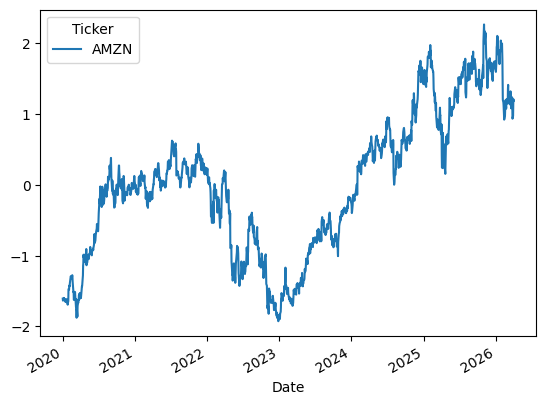

In [ ]:
df.Close.plot()

In [ ]:
seq_length = 30
data =[]


for i in range(len(df) - seq_length):
  data.append(df.Close[i:i+seq_length])



In [ ]:
data

In [ ]:
data = np.array(data)

train_size = int(0.8 * len(data))


In [ ]:
X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor)
X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor)

In [ ]:
class Mymodel(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers, output_size):
    super(Mymodel, self).__init__()

    self.num_layers = num_layers
    self.hidden_size = hidden_size
    self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
    c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

    out, _ = self.lstm(x, (h0, c0)) # LSTM returns output and (h_n, c_n)
    out = self.fc(out[:, -1, :]) # Take the output from the last time step
    return out

In [ ]:
model = Mymodel(input_size=1, hidden_size=32, num_layers=2, output_size=1)

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
num_epochs = 200


for i in range(num_epochs):
  y_train_pred = model(X_train)

  loss = criterion(y_train_pred, y_train)


  if i % 25 == 0:
    print(i, loss.item())

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

0 0.7741289138793945
25 0.023404894396662712
50 0.010373200289905071
75 0.00872949231415987
100 0.007902632467448711
125 0.007247720379382372
150 0.0067236716859042645
175 0.006319629028439522


In [ ]:
model.eval()
y_test_pred = model(X_test)
# Re-calculate y_train_pred after setting model to eval mode to ensure it's a fresh tensor
y_train_pred_tensor = model(X_train)

y_train_pred = scaler.inverse_transform(y_train_pred_tensor.detach().numpy())
y_train = scaler.inverse_transform(y_train.detach().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().numpy())
y_test = scaler.inverse_transform(y_test.detach().numpy())

In [ ]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

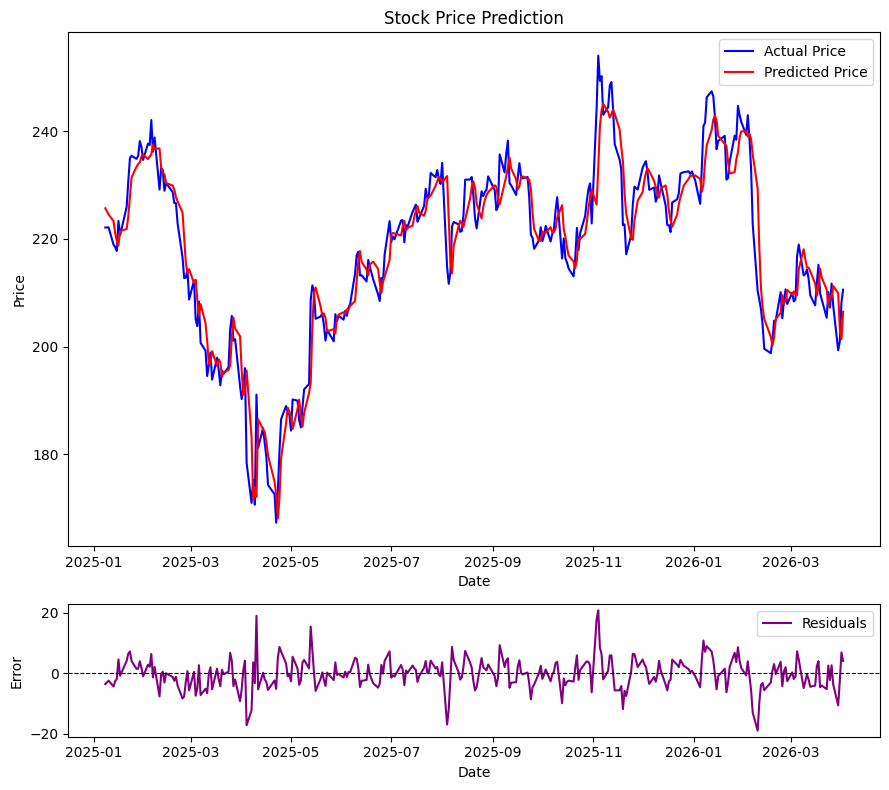

In [ ]:
fig = plt.figure(figsize=(9, 8))

gs = fig.add_gridspec(4, 1)

# Calculate the corresponding index for the test data
test_index = df.index[-len(y_test):]

# Main price plot (top 3 rows)
ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(test_index, y_test, color='blue', label='Actual Price')
ax1.plot(test_index, y_test_pred, color='red', label='Predicted Price')
ax1.legend()
ax1.set_title("Stock Price Prediction")
ax1.set_xlabel("Date")
ax1.set_ylabel("Price")

# Residual plot (bottom row)
ax2 = fig.add_subplot(gs[3, 0])
residuals = y_test - y_test_pred
ax2.plot(test_index, residuals, color='purple', label='Residuals')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax2.set_xlabel("Date")
ax2.set_ylabel("Error")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:

# Calculate RMSE for training and testing sets
train_rmse = root_mean_squared_error(y_train, y_train_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)

print(f'Train RMSE: {train_rmse:.4f}')
print(f'Test RMSE: {test_rmse:.4f}')

Train RMSE: 3.2005
Test RMSE: 4.9758


##  Feature Engineering (Technical Indicators)

In [ ]:
import ta
import warnings
warnings.filterwarnings('ignore')

ticker = 'AMZN'
df_raw = yf.download(ticker, '2020-01-01', auto_adjust=True)
df_raw.columns = df_raw.columns.get_level_values(0)
df_raw = df_raw[['Open','High','Low','Close','Volume']].dropna()

close = df_raw['Close']
high  = df_raw['High']
low   = df_raw['Low']
vol   = df_raw['Volume']

df_raw['RSI']         = ta.momentum.RSIIndicator(close, window=14).rsi()
df_raw['MACD']        = ta.trend.MACD(close).macd()
df_raw['MACD_signal'] = ta.trend.MACD(close).macd_signal()
df_raw['BB_upper']    = ta.volatility.BollingerBands(close).bollinger_hband()
df_raw['BB_lower']    = ta.volatility.BollingerBands(close).bollinger_lband()
df_raw['ATR']         = ta.volatility.AverageTrueRange(high, low, close).average_true_range()
df_raw['OBV']         = ta.volume.OnBalanceVolumeIndicator(close, vol).on_balance_volume()
df_raw['EMA_20']      = ta.trend.EMAIndicator(close, window=20).ema_indicator()
df_raw['ROC']         = ta.momentum.ROCIndicator(close, window=10).roc()

df_raw.dropna(inplace=True)
print(df_raw.shape, df_raw.columns.tolist())
df_raw.tail(3)


[*********************100%***********************]  1 of 1 completed

(1538, 14) ['Open', 'High', 'Low', 'Close', 'Volume', 'RSI', 'MACD', 'MACD_signal', 'BB_upper', 'BB_lower', 'ATR', 'OBV', 'EMA_20', 'ROC']


Price,Open,High,Low,Close,Volume,RSI,MACD,MACD_signal,BB_upper,BB_lower,ATR,OBV,EMA_20,ROC
Date,,,,,,,,,,,,,,
2026-03-31,204.850006,210.279999,204.139999,208.270004,58470100,48.106038,-2.711841,-2.507107,219.605929,200.671071,5.959150,4265718300,208.745284,-3.220257
2026-04-01,210.440002,213.580002,208.190002,210.570007,45955400,50.422447,-2.243686,-2.454423,218.789834,200.862166,5.918497,4311673700,208.919067,0.333546
2026-04-02,206.539993,212.210007,204.899994,209.770004,31405300,49.593229,-1.915147,-2.346567,217.298266,201.436734,6.017891,4280268400,209.000109,0.483814


## PyTorch Data Augmentation

In [ ]:
from torch.utils.data import Dataset, DataLoader

FEATURE_COLS = ['Close','RSI','MACD','MACD_signal','BB_upper','BB_lower','ATR','OBV','EMA_20','ROC']
SEQ_LEN      = 30

from sklearn.preprocessing import StandardScaler
feat_scaler  = StandardScaler()
close_scaler = StandardScaler()

feat_data  = feat_scaler.fit_transform(df_raw[FEATURE_COLS].values)
close_data = close_scaler.fit_transform(df_raw[['Close']].values)

X_seq, y_seq = [], []
for i in range(len(feat_data) - SEQ_LEN):
    X_seq.append(feat_data[i:i+SEQ_LEN])
    y_seq.append(close_data[i+SEQ_LEN])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

split = int(0.8 * len(X_seq))
X_tr, y_tr = X_seq[:split], y_seq[:split]
X_te, y_te = X_seq[split:], y_seq[split:]


class AugmentedStockDataset(Dataset):
    """
    Two augmentation strategies applied during training only:
      1. Gaussian noise  — randomly perturbs each time step
      2. Magnitude scale — uniformly scales the whole window
    Both preserve temporal shape while adding training diversity.
    """
    def __init__(self, X, y, augment=True, noise_std=0.01, scale_range=(0.95, 1.05)):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.augment     = augment
        self.noise_std   = noise_std
        self.scale_range = scale_range

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y[idx].clone()
        if self.augment:
            x = x + torch.randn_like(x) * self.noise_std
            scale = torch.FloatTensor(1).uniform_(*self.scale_range)
            x = x * scale
        return x, y


train_ds = AugmentedStockDataset(X_tr, y_tr, augment=True)
test_ds  = AugmentedStockDataset(X_te, y_te, augment=False)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

print(f'Train sequences: {len(train_ds)} | Test sequences: {len(test_ds)}')
print(f'Features per timestep: {len(FEATURE_COLS)}')


Train sequences: 1206 | Test sequences: 302
Features per timestep: 10


## — Enhanced LSTM + Optuna Hyperparameter Tuning

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


class EnhancedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, num_layers,
                               batch_first=True,
                               dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = self.dropout(out[:, -1, :])
        return self.fc(out)


def train_lstm_trial(trial):
    hidden = trial.suggest_categorical('hidden_size', [32, 64, 128])
    layers = trial.suggest_int('num_layers', 1, 3)
    drop   = trial.suggest_float('dropout', 0.0, 0.4)
    lr     = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    model = EnhancedLSTM(len(FEATURE_COLS), hidden, layers, drop)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    crit  = nn.MSELoss()

    model.train()
    for _ in range(60):  # quick training for search
        for xb, yb in train_loader:
            pred = model(xb)
            loss = crit(pred, yb)
            opt.zero_grad(); loss.backward(); opt.step()

    model.eval()
    preds, acts = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            preds.append(model(xb)); acts.append(yb)
    preds = torch.cat(preds).numpy()
    acts  = torch.cat(acts).numpy()
    return np.sqrt(((preds - acts) ** 2).mean())


study_lstm = optuna.create_study(direction='minimize')
study_lstm.optimize(train_lstm_trial, n_trials=15, show_progress_bar=True)

print('\nBest LSTM params:', study_lstm.best_params)
print(f'Best LSTM val RMSE (scaled): {study_lstm.best_value:.6f}')


  0%|          | 0/15 [00:00<?, ?it/s]


Best LSTM params: {'hidden_size': 128, 'num_layers': 1, 'dropout': 0.06926160358165415, 'lr': 0.00047786213276924884}
Best LSTM val RMSE (scaled): 0.146412


In [ ]:
best = study_lstm.best_params
final_lstm = EnhancedLSTM(len(FEATURE_COLS), best['hidden_size'],
                          best['num_layers'], best['dropout'])
final_opt  = torch.optim.Adam(final_lstm.parameters(), lr=best['lr'])
crit       = nn.MSELoss()

final_lstm.train()
for epoch in range(150):
    ep_loss = 0
    for xb, yb in train_loader:
        pred = final_lstm(xb)
        loss = crit(pred, yb)
        final_opt.zero_grad(); loss.backward(); final_opt.step()
        ep_loss += loss.item()
    if epoch % 30 == 0:
        print(f'Epoch {epoch:3d} | loss: {ep_loss/len(train_loader):.6f}')

final_lstm.eval()
preds_lstm, acts_lstm = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds_lstm.append(final_lstm(xb))
        acts_lstm.append(yb)

preds_lstm = close_scaler.inverse_transform(torch.cat(preds_lstm).numpy())
acts_lstm  = close_scaler.inverse_transform(torch.cat(acts_lstm).numpy())
from sklearn.metrics import root_mean_squared_error
lstm_rmse  = root_mean_squared_error(acts_lstm, preds_lstm)
print(f'\nFinal LSTM Test RMSE: ${lstm_rmse:.4f}')


Epoch   0 | loss: 0.480640
Epoch  30 | loss: 0.008593
Epoch  60 | loss: 0.007619
Epoch  90 | loss: 0.007416
Epoch 120 | loss: 0.007188

Final LSTM Test RMSE: $6.2032


##  — XGBoost Model + Optuna Tuning

In [ ]:
import xgboost as xgb

# Flatten sequences for XGBoost: (N, seq_len * n_features)
X_tr_flat = X_tr.reshape(len(X_tr), -1)
X_te_flat = X_te.reshape(len(X_te), -1)
y_tr_1d   = y_tr.ravel()
y_te_1d   = y_te.ravel()


def xgb_trial(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 600),
        max_depth        = trial.suggest_int('max_depth', 3, 8),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
        tree_method      = 'hist',
        random_state     = 42,
    )
    m = xgb.XGBRegressor(**params, verbosity=0)
    m.fit(X_tr_flat, y_tr_1d, eval_set=[(X_te_flat, y_te_1d)], verbose=False)
    pred = m.predict(X_te_flat)
    return np.sqrt(((pred - y_te_1d) ** 2).mean())


study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(xgb_trial, n_trials=30, show_progress_bar=True)

print('\nBest XGBoost params:', study_xgb.best_params)
print(f'Best XGBoost val RMSE (scaled): {study_xgb.best_value:.6f}')


  0%|          | 0/30 [00:00<?, ?it/s]


Best XGBoost params: {'n_estimators': 232, 'max_depth': 5, 'learning_rate': 0.24434892261343363, 'subsample': 0.815211386381647, 'colsample_bytree': 0.8352918683902458, 'min_child_weight': 2, 'reg_alpha': 0.010112542631629676, 'reg_lambda': 0.0878300134076311}
Best XGBoost val RMSE (scaled): 0.245551


In [ ]:
best_xgb_params = study_xgb.best_params.copy()
best_xgb_params.update({'tree_method': 'hist', 'random_state': 42, 'verbosity': 0})

final_xgb = xgb.XGBRegressor(**best_xgb_params)
final_xgb.fit(X_tr_flat, y_tr_1d)

preds_xgb = close_scaler.inverse_transform(final_xgb.predict(X_te_flat).reshape(-1, 1))
acts_xgb  = close_scaler.inverse_transform(y_te_1d.reshape(-1, 1))
xgb_rmse  = root_mean_squared_error(acts_xgb, preds_xgb)
print(f'Final XGBoost Test RMSE: ${xgb_rmse:.4f}')


Final XGBoost Test RMSE: $9.9387


Part 5 — Model Comparison Dashboard

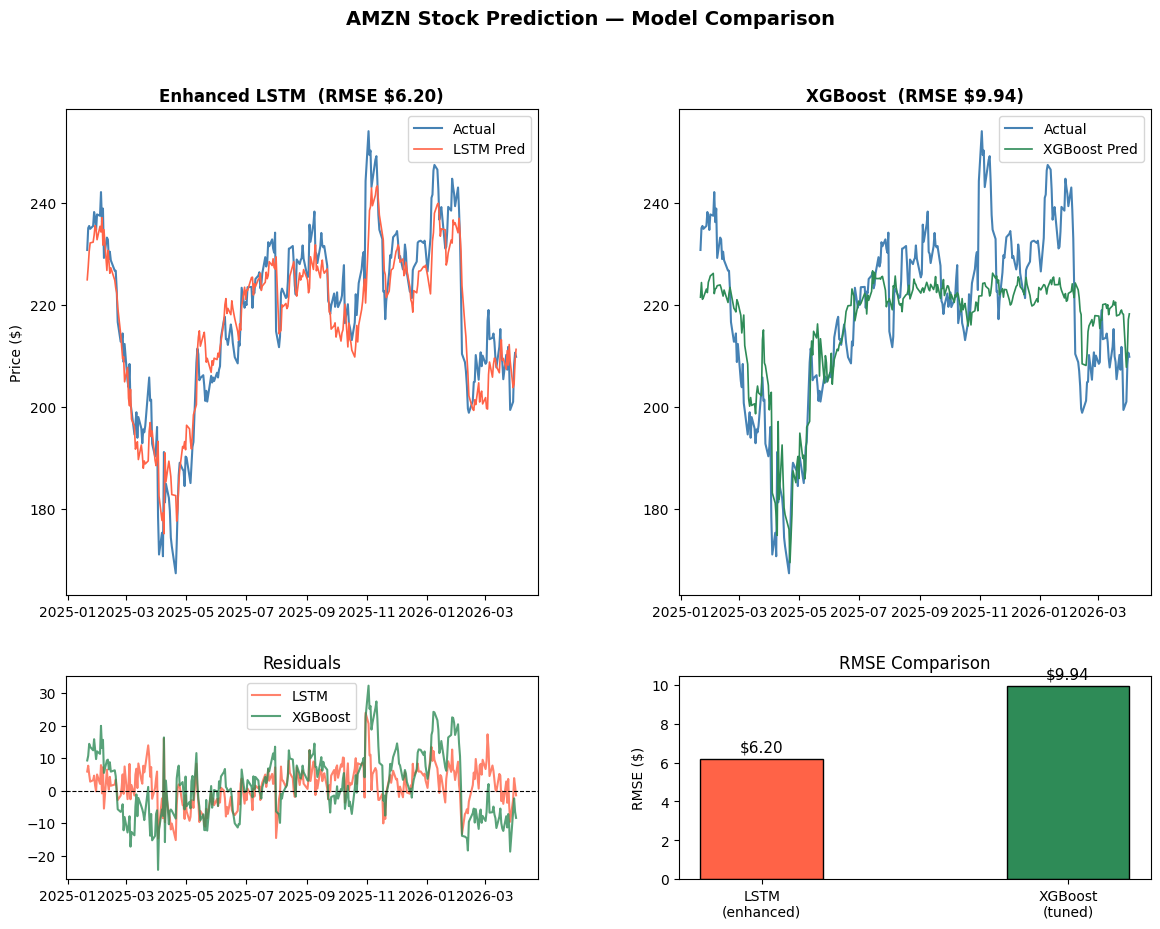


LSTM RMSE:    $6.2032
XGBoost RMSE: $9.9387
Winner: LSTM


In [ ]:
import matplotlib.gridspec as gridspec

test_index = df_raw.index[-len(acts_lstm):]

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)

# Top-left: LSTM
ax1 = fig.add_subplot(gs[0:2, 0])
ax1.plot(test_index, acts_lstm,  color='steelblue',  label='Actual',    lw=1.5)
ax1.plot(test_index, preds_lstm, color='tomato',     label='LSTM Pred', lw=1.2)
ax1.set_title(f'Enhanced LSTM  (RMSE ${lstm_rmse:.2f})', fontweight='bold')
ax1.legend(); ax1.set_ylabel('Price ($)')

# Top-right: XGBoost
ax2 = fig.add_subplot(gs[0:2, 1])
ax2.plot(test_index, acts_xgb,   color='steelblue',  label='Actual',       lw=1.5)
ax2.plot(test_index, preds_xgb,  color='seagreen',   label='XGBoost Pred', lw=1.2)
ax2.set_title(f'XGBoost  (RMSE ${xgb_rmse:.2f})', fontweight='bold')
ax2.legend()

# Bottom-left: residuals
ax3 = fig.add_subplot(gs[2, 0])
ax3.plot(test_index, acts_lstm - preds_lstm, color='tomato',   label='LSTM',    alpha=0.8)
ax3.plot(test_index, acts_xgb  - preds_xgb, color='seagreen', label='XGBoost', alpha=0.8)
ax3.axhline(0, color='black', ls='--', lw=0.8)
ax3.set_title('Residuals'); ax3.legend()

# Bottom-right: RMSE bar
ax4 = fig.add_subplot(gs[2, 1])
bars = ax4.bar(['LSTM\n(enhanced)', 'XGBoost\n(tuned)'],
               [lstm_rmse, xgb_rmse],
               color=['tomato', 'seagreen'], width=0.4, edgecolor='black')
ax4.bar_label(bars, fmt='$%.2f', padding=3, fontsize=11)
ax4.set_title('RMSE Comparison'); ax4.set_ylabel('RMSE ($)')

fig.suptitle('AMZN Stock Prediction — Model Comparison', fontsize=14, fontweight='bold')
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nLSTM RMSE:    ${lstm_rmse:.4f}')
print(f'XGBoost RMSE: ${xgb_rmse:.4f}')
print(f'Winner: {"LSTM" if lstm_rmse < xgb_rmse else "XGBoost"}')
